# Statcast Dataset Build Pipeline

生 Statcast CSV から学習用データセットを構築するパイプライン。

| Step | 内容 |
|------|------|
| 1. Filter | 2000球以上の打者を抽出 |
| 2. Features | カラム選択・ゲームステート・軌道特徴量・正規化 |
| 3. Labels | description解析・カテゴリカルエンコード・stats生成 |
| 4. Splits | 時系列分割・打者履歴構築・保存 |
| 5. Quality | ソースデータの品質レポート（構築処理の成否ではない） |

In [1]:
import sys

sys.path.insert(0, "/workspace/atbat-dynamics-model")

SOURCE_DIR = "/workspace/datasets/statcast"
OUTPUT_DIR = "/workspace/datasets/statcast-customized-v2"

## Step 1: Filter — 打者フィルタ

=== Step 1: Filter (min 2000 pitches) ===
  打者数: 4,161 → 783
  投球数: 6,360,261 → 5,781,569
  保持率: 90.9%


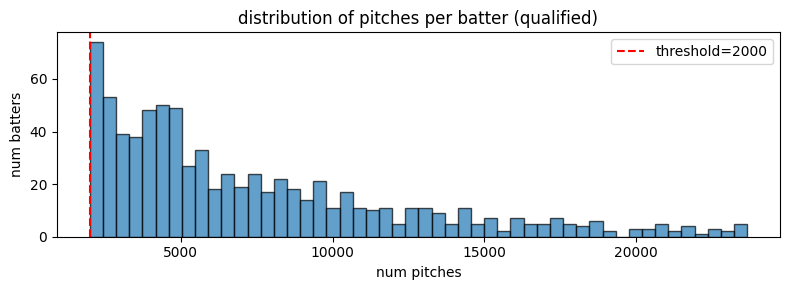

In [2]:
from tools.build_dataset import step_filter

df, filter_report = step_filter.run(SOURCE_DIR)
filter_report.display()

## Step 2: Feature Engineering — 特徴量エンジニアリング

In [3]:
from tools.build_dataset import step_features

df, features_report = step_features.run(df)
features_report.display()

=== Step 2: Feature Engineering ===
  行数: 5,781,569
  打席数: 1,493,291
  カラム数: 40

  欠損値:


,column,null_count,null_pct
0,hc_x,4776431,82.61%
1,hc_y,4776431,82.61%
2,spray_angle,4776431,82.61%
3,bb_type,4765438,82.42%
4,hit_distance_sc,4032299,69.74%
5,launch_speed,4004282,69.26%
6,launch_angle,4003018,69.24%
7,release_spin_rate,149937,2.59%
8,plate_z_norm,100496,1.74%
9,plate_x,100453,1.74%



  カラム一覧: ['at_bat_id', 'description', 'bb_type', 'launch_speed', 'launch_angle', 'hit_distance_sc', 'hc_x', 'hc_y', 'spray_angle', 'p_throws', 'pitch_type', 'batter', 'stand', 'base_out_state', 'count_state', 'release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'plate_z_norm', 'inning_clipped', 'is_inning_top', 'diff_score_clipped', 'pitch_number_clipped', 'game_pk', 'game_date', 'pitcher', 'home_team', 'away_team', 'at_bat_number']


## Step 3: Labels — ラベル生成・エンコーディング

In [4]:
from tools.build_dataset import step_labels

df, labels_report = step_labels.run(df)
labels_report.display()

=== Step 3: Labels ===

  スイング内訳:
    swing: 2,734,513
    no_swing: 3,047,056

  swing_result 分布:


,class,count
0,foul,1081104
1,hit_into_play,1016206
2,miss,637203



  bb_type 分布:


,class,count
0,ground_ball,438621
1,fly_ball,257052
2,line_drive,248084
3,popup,72374


## Step 4: Splits & Save — 分割・保存

In [5]:
from tools.build_dataset import step_splits

df, splits_report = step_splits.run(df, labels_report.stats_tables, OUTPUT_DIR)
splits_report.display()

=== Step 4: Splits & Save ===

  分割サイズ (at_bat_id数):
    train: 1,238,917 (2017-04-02 ~ 2024-06-30)
    valid: 84,541 (2024-07-01 ~ 2024-10-30)
    test: 169,833 (2025-03-15 ~ 2025-11-01)

  打者履歴:
    エントリ数: 398,925
    平均履歴長: 49.2
    最大履歴長: 50

  投手履歴:
    エントリ数: 189,469
    平均履歴長: 47.1
    最大履歴長: 50


## Step 5: Data Quality Report — ソースデータ品質レポート

データセット構築は Step 4 で完了しています。  
このステップは Statcast ソースデータ自体の品質を確認するためのレポートです。

In [6]:
from tools.build_dataset import step_validate

validate_report = step_validate.run(df)
validate_report.display()

=== Step 5: Data Quality Report ===
  データセット構築は正常に完了しています。
  以下はソースデータ (Statcast) 自体の品質レポートです。



,quality,check,outliers,rate,detail
0,---,no_swing→swing_result=NaN,,,
1,---,no_swing→bb_type=NaN,,,
2,---,no_swing→launch_speed=NaN,,,
3,---,no_swing→launch_angle=NaN,,,
4,---,no_swing→hit_distance_sc=NaN,,,
5,---,no_swing→hc_x=NaN,,,
6,---,no_swing→hc_y=NaN,,,
7,---,not_hit→bb_type=NaN,,,
8,---,not_hit→hc_x=NaN,,,
9,---,not_hit→hc_y=NaN,,,



  NOTABLE: 1 件 — ソースデータに 0.1% 以上の外れ値があります。
  （Statcast の分類誤差による既知の現象で、モデル学習への影響は軽微です）
  minor: 4 件 — 軽微な外れ値（0.1% 未満）


---
## Done

データセットが `OUTPUT_DIR` に保存されました。